#numero es par o 5 

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9547 - loss: 0.1202 - val_accuracy: 0.9730 - val_loss: 0.0825
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9801 - loss: 0.0576 - val_accuracy: 0.9797 - val_loss: 0.0621
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9848 - loss: 0.0443 - val_accuracy: 0.9845 - val_loss: 0.0484
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9877 - loss: 0.0345 - val_accuracy: 0.9818 - val_loss: 0.0538
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9903 - loss: 0.0281 - val_accuracy: 0.9825 - val_loss: 0.0629
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9828 - loss: 0.0570
precision en test. 0.98


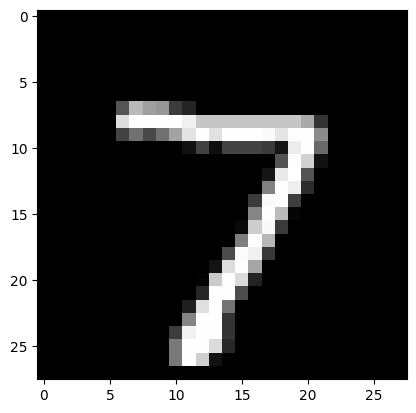

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
probabiliadd de que sea : 0.00


In [ ]:
import numpy as np 
import tensorflow as tf
import matplotlib.pyplot as plt 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
#cargar los datos del mnist 
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train/255.0
x_test = x_test/255.0
#indicar que los numeros 5 son valor 1 y los que no lo sean seran valor 0 entrenandolo para que solo pueda reconocer el 5 

# entrena solo para los numeros 5
#y_train_binary = np.where(y_train== 5,1,0)
#y_test_binary = np.where(y_test==5,1,0)


y_train_binary = np.where(y_train%2== 0,1,0)
y_test_binary = np.where(y_test%2==0,1,0)

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer= 'adam',
    loss = 'binary_crossentropy',
    metrics=['accuracy'])

model.fit(x_train, y_train_binary, epochs=5, batch_size=32, validation_split=0.1)
loss, accuracy = model.evaluate(x_test, y_test_binary)
print(f"precision en test. {accuracy:.2f}")
index = 0

plt.imshow(x_test[index],cmap='gray')
plt.show()

prediction = model.predict(x_test[index].reshape(1,28,28))
print(f"probabiliadd de que sea : {prediction[0][0]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


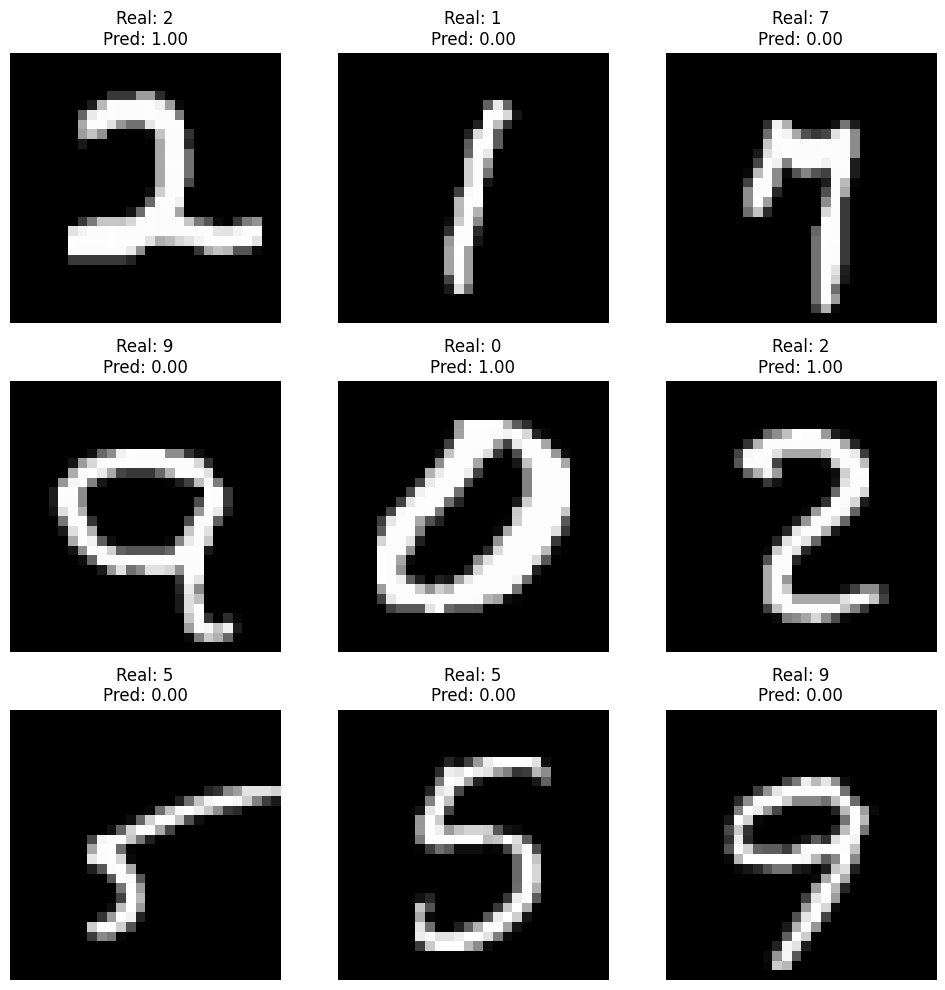

In [14]:
import matplotlib.pyplot as plt
import numpy as np

num_images = 9
indices = np.random.choice(len(x_test), num_images, replace=False)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(indices):
    img = x_test[idx]
    real_digit = y_test[idx]

    pred = model.predict(img.reshape(1, 28, 28))[0]
    predicted_digit = np.argmax(pred)
    probability = pred[predicted_digit]

    plt.subplot(3, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(
        f"Real: {real_digit}\n"
        f"Pred: {probability:.2f}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()


#numero par o impar 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


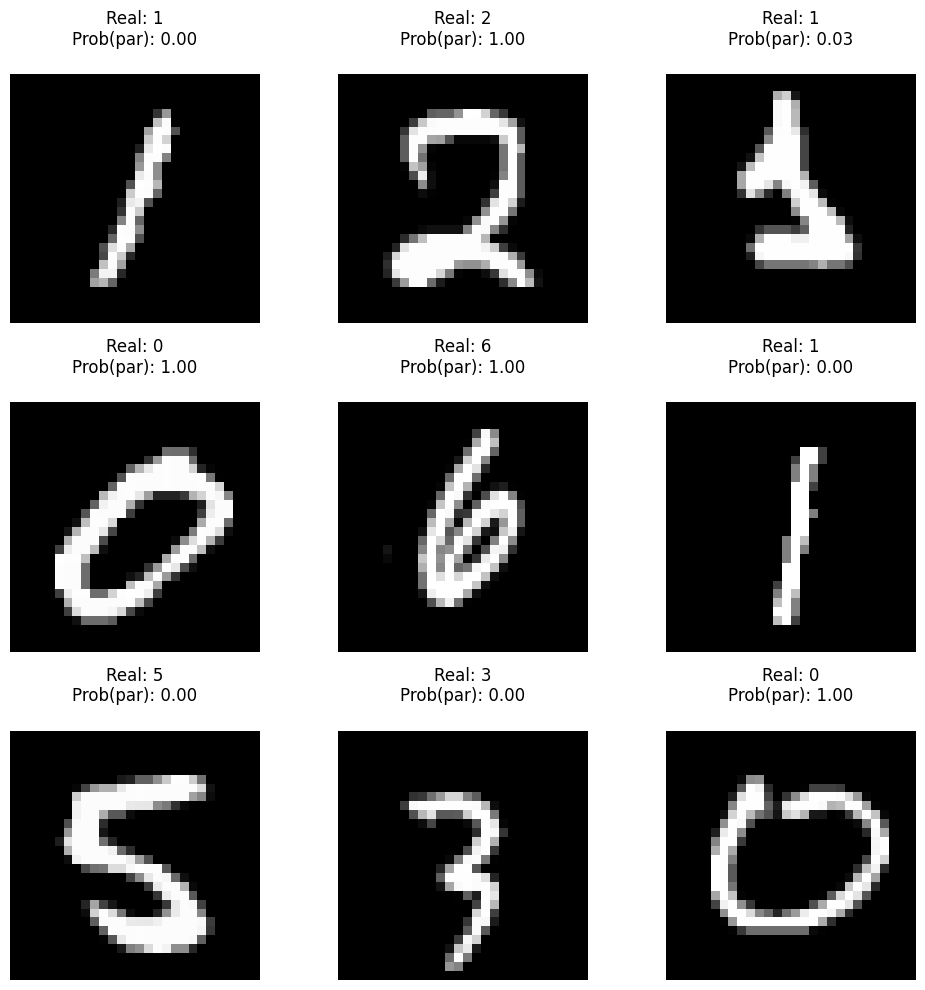

In [15]:
import matplotlib.pyplot as plt 
import numpy as np 

num_images= 9 
indices = np.random.choice(len(x_test),num_images, replace=False)
plt.figure(figsize= (10,10))

for i, idx in enumerate(indices):
    img=x_test[idx]
    real_digit = y_test[idx]
    pred_prob = model.predict(img.reshape(1,28,28))[0][0]
    
    plt.subplot (3,3,i+1)
    plt.imshow(img, cmap = 'gray')
    plt.title(
        f"Real: {real_digit}\n"
        f"Prob(par): {pred_prob:.2f}\n"
        
    )
    plt.axis('off')
plt.tight_layout()
plt.show()

#numeros grandes vs pequeños 

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9986 - loss: 0.0044 - val_accuracy: 0.9832 - val_loss: 0.1084
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9984 - loss: 0.0051 - val_accuracy: 0.9823 - val_loss: 0.1014
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9827 - val_loss: 0.0915
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9987 - loss: 0.0035 - val_accuracy: 0.9830 - val_loss: 0.1037
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9982 - loss: 0.0053 - val_accuracy: 0.9842 - val_loss: 0.1041
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9841 - loss: 0.1111
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9841 - loss: 0.1111
precision en test. 0.98
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4

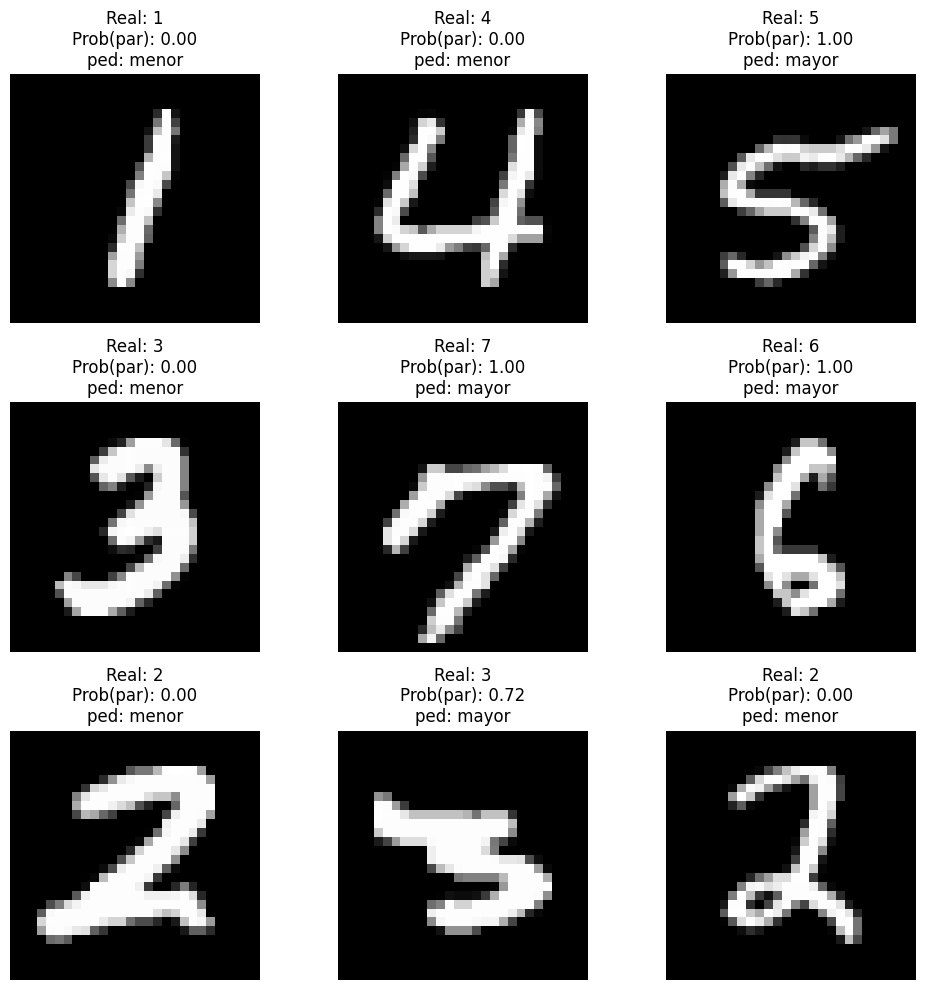

In [20]:
y_train_binary = np.where(y_train< 5,0,1)
y_test_binary = np.where(y_test< 5,0,1)

model.fit(x_train, y_train_binary, epochs=5, batch_size=32, validation_split=0.1)
loss, accuracy = model.evaluate(x_test, y_test_binary)
index = 0
prediction = model.predict(x_test[index].reshape(1,28,28))
num_images= 9 
indices = np.random.choice(len(x_test),num_images, replace=False)
plt.figure(figsize= (10,10))

loss, accuracy = model.evaluate(x_test, y_test_binary)
print(f"precision en test. {accuracy:.2f}")

for i, idx in enumerate(indices):
    img=x_test[idx]
    real_digit = y_test[idx]
    pred_prob = model.predict(img.reshape(1,28,28))[0][0]
    pred = "mayor" if pred_prob > 0.5 else "menor"
    plt.subplot (3,3,i+1)
    plt.imshow(img, cmap = 'gray')
    plt.title(
        f"Real: {real_digit}\n"
        f"Prob(par): {pred_prob:.2f}\n"
        f"ped: {pred}"
    )
    plt.axis('off')
plt.tight_layout()
plt.show()
